# Implementation for ResDiff (ResDiff: Combining CNN and Diffusion Model for Image Super-Resolution)

https://arxiv.org/abs/2303.08714

https://github.com/LYL1015/ResDiff/tree/master

- Training a CNN to predict the primary low-frequency content of the LR image
- Training a Diffusion model (U-Net) to predict the intricate high-frequency details.

In [ ]:
# !pip install -U xformers --index-url https://download.pytorch.org/whl/cu126
!pip install basicsr bitsandbytes monai nibabel nilearn SimpleITK torchmetrics scikit-image pytorch-wavelets pydicom torchmetrics[image]

In [ ]:
import os

# Clone the official ResDiff repository
!git clone https://github.com/LYL1015/ResDiff.git

fatal: destination path 'ResDiff' already exists and is not an empty directory.


In [ ]:
import sys
sys.path.append('./ResDiff')
sys.path.append('./ResDiff/models')

In [ ]:
import argparse
import functools
import gc
import logging
import math
import os
import random
import shutil
from pathlib import Path
import wandb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from accelerate import Accelerator
import diffusers
from diffusers import (
    AutoencoderKL,
    ControlNetModel,
    DDPMScheduler,
    UNet2DModel,
    UNet2DConditionModel,
    UniPCMultistepScheduler,
)
from diffusers.optimization import get_scheduler
from diffusers.utils import check_min_version, is_wandb_available
from diffusers.utils.import_utils import is_xformers_available
from diffusers.training_utils import EMAModel

from omegaconf import OmegaConf
import cv2
from huggingface_hub import hf_hub_url
import subprocess
import shlex

# from mri_diffusion_sr.src.adapters.utils import (import_model_class_from_model_name_or_path, log_configs, encode_prompt_sd1x5, compute_embeddings_sd1x5)

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Library changes

In [ ]:
# Changes necessary to solve the hardcoded path problem.
import os

# 1. Identify the file path (Update this if the file is in a different subfolder)
file_path = '/content/ResDiff/model/resdiff_modules/diffusion.py'

# 2. Define the exact text to find (matching the multi-line structure)
target_text = """self.cnn.load_state_dict(torch.load('/home/lyu4/ssy/'
                                            'Image-Super-Resolution-via-Iterative-Refinement-master/'
                                            'pretrain_CNN/cnn_weights.pth'))"""

# 3. Define the replacement (single line Colab path)
replacement_text = "self.cnn.load_state_dict(torch.load('./models/cnn_weights.pth'))"

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    if target_text in content:
        new_content = content.replace(target_text, replacement_text)
        with open(file_path, 'w') as f:
            f.write(new_content)
        print("Successfully patched the hardcoded path!")
    else:
        # If the indentation or line breaks are slightly different,
        # let's try a more flexible regex-style replacement
        import re
        # This regex looks for 'torch.load' and everything inside its parentheses
        # until it finds the '.pth' string.
        pattern = r"torch\.load\('/home/lyu4/ssy/.*?cnn_weights\.pth'\)"
        new_content = re.sub(pattern, "torch.load('./models/cnn_weights.pth')", content, flags=re.DOTALL)

        with open(file_path, 'w') as f:
            f.write(new_content)
        print("Patched using flexible pattern matching.")
else:
    print(f"File not found at {file_path}. Please check the folder structure.")

Patched using flexible pattern matching.


In [ ]:
import os

file_path = '/content/ResDiff/model/resdiff_modules/diffusion.py'

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        content = f.read()

    # Change the hardcoded scale_factor from 4 to 1 to match your checkpoint
    old_init = "self.cnn = SimpleCNN(scale_factor=4)"
    new_init = "self.cnn = SimpleCNN(scale_factor=1)"

    if old_init in content:
        new_content = content.replace(old_init, new_init)
        with open(file_path, 'w') as f:
            f.write(new_content)
        print("Successfully updated diffusion.py to use scale_factor=1")
    else:
        print("Could not find the scale_factor=4 line. It might already be patched.")
else:
    print(f"File not found at {file_path}")

# IMPORTANT: After patching the file, you MUST clear the python cache
# so the change takes effect in the imported module
import sys
if 'model.resdiff_modules.diffusion' in sys.modules:
    del sys.modules['model.resdiff_modules.diffusion']
if 'model.networks' in sys.modules:
    del sys.modules['model.networks']
if 'model.model' in sys.modules:
    del sys.modules['model.model']

Could not find the scale_factor=4 line. It might already be patched.


In [ ]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pytorch_wavelets as pw

# Import the original module to get access to ResSE, Block, etc.
import model.resdiff_modules.unet as unet_mod
from model.resdiff_modules.unet import ResSE, Block, ResnetBlocWithAttn, exists, PositionalEncoding, Swish

# --- FIX 3: ResSE to prevent 1//2 = 0 error ---

class ResSE_Fixed(nn.Module):
    def __init__(self, ch_in, reduction=2):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        # FIX: Ensure bottleneck_ch is at least 1
        bottleneck_ch = max(1, ch_in // reduction)

        self.fc = nn.Sequential(
            nn.Linear(ch_in, bottleneck_ch, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck_ch, ch_in, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        tmp = x
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x) + tmp

# --- FIX 1: Redefine FD_Info_Spliter for 1-channel ---
class FD_Info_Spliter_New(nn.Module):
    def __init__(self, dim, in_channels, out_channels, image_size):
        super().__init__()

        in_channels = 1
        self.dim = dim
        self.image_size = image_size
        self.noise_func = nn.Linear(dim, image_size)

        self.noise_resSE = ResSE_Fixed(in_channels)
        self.sigma_resSE = ResSE_Fixed(in_channels * 2)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.HF_guided_resSE = ResSE_Fixed(in_channels * 2)

        self.channel_transform = nn.Conv2d(2 * in_channels, in_channels, 1) # 2 -> 1 for grayscale

    def forward(self, x, noise_embed):
        # MODIFIED: Split by 1 channel instead of 3
        cnn_x, x = torch.split(x, x.shape[1] // 2, dim=1)

        assert x.shape == cnn_x.shape
        # Noise image suppression
        b, c, h, w = x.shape
        noise_embed = self.noise_func(noise_embed.view(b, -1))
        noise_embed = noise_embed.unsqueeze(1).unsqueeze(2).repeat(1, 1, self.image_size, 1)
        noise_atten = self.noise_resSE(noise_embed)
        denoise_x = x * noise_atten

        # High and low frequency information separation
        n, m = x.shape[-2:]
        device = x.device

        # create frequency grid
        xx = torch.arange(n, dtype=torch.float, device=device)
        yy = torch.arange(m, dtype=torch.float, device=device)
        u, v = torch.meshgrid(xx, yy)
        u = u - n / 2
        v = v - m / 2

        # convert tensor to complex tensor and apply FFT
        tensor_complex = torch.stack([cnn_x, torch.zeros_like(cnn_x)], dim=-1)
        tensor_complex = torch.view_as_complex(tensor_complex)
        tensor_fft = torch.fft.fftn(tensor_complex)

        # Concat the real and imaginary parts
        x_real, x_imag = torch.real(tensor_fft), torch.imag(tensor_fft)
        x_fd = torch.cat([x_real, x_imag], dim=1)

        # get sigma, numerical stabilization was performed
        sigma_pre = torch.abs(torch.mean(self.avg_pool(self.sigma_resSE(x_fd)), dim=1)) + self.image_size/2
        sigma_min = torch.tensor(self.image_size-10, device=device).view(1, 1, 1).expand_as(sigma_pre)
        sigma = torch.minimum(sigma_pre, sigma_min)

        # calculate Gaussian high-pass filter
        D = torch.sqrt(u ** 2 + v ** 2).to(device)
        H = 1 - torch.exp(-D ** 2 / (2 * sigma ** 2))
        H = H.to(device).unsqueeze(1)

        # apply Gaussian high-pass filter to FFT
        tensor_filtered_fft = tensor_fft * H

        # get Frequency-domain guided attention weight,thus obtain Low-frequency feature map
        x_real_filterd, x_imag_filterd = torch.real(tensor_filtered_fft), torch.imag(tensor_filtered_fft)
        x_fd_filterd = torch.cat([x_real_filterd, x_imag_filterd], dim=1)
        x_hf_guided_atten = self.HF_guided_resSE(x_fd_filterd)

        x_lf_feature = cnn_x * self.channel_transform(x_hf_guided_atten)

        # IFFT，get High-frequency feature map
        tensor_filtered = torch.fft.ifftn(tensor_filtered_fft)
        x_hf_feature = torch.abs(tensor_filtered)

        return torch.cat([x, cnn_x, denoise_x, x_lf_feature, x_hf_feature], dim=1)

# --- FIX 2: Redefine HF_guided_CA for 1-channel ---
class HF_guided_CA_New(nn.Module):
    def __init__(self, in_channel, norm_groups=32):
        super().__init__()
        self.norm = nn.GroupNorm(norm_groups, in_channel)
        self.q = nn.Conv2d(1, in_channel, 1, bias=False) # MODIFIED: 3 -> 1
        self.kv = nn.Conv2d(in_channel, in_channel * 2, 1, bias=False)
        self.out = nn.Conv2d(in_channel, in_channel, 1)

    def forward(self, input, quary):
        batch, channel, height, width = input.shape
        norm = self.norm(input)
        kv = self.kv(norm).view(batch, 1, channel * 2, height, width)
        key, value = kv.chunk(2, dim=2)
        quary = self.q(quary).unsqueeze(1)
        attn = torch.einsum("bnchw, bncyx -> bnhwyx", quary, key).contiguous() / math.sqrt(channel)
        attn = torch.softmax(attn.view(batch, 1, height, width, -1), -1).view(batch, 1, height, width, height, width)
        out = torch.einsum("bnhwyx, bncyx -> bnchw", attn, value).contiguous()
        return self.out(out.view(batch, channel, height, width)) + input

In [ ]:
# --- FIX 4: UNET to prevent the hardcoded 3 dim. ---
def patched_unet_forward(self, x, time):
    # MODIFIED: Split by 1 channel instead of 3
    dwt_x, _ = torch.split(x, x.shape[1] // 2, dim=1)

    J = self.J
    dwt_img_list = []
    dwt_f = pw.DWTForward(J=J, wave='haar', mode='symmetric').to(x.device)

    # DWT on grayscale yields fewer coefficients, we sum them
    # For grayscale, YL is [B, 1, H, W], YH is a list of [B, 1, 3, H', W']
    _, x_dwt_high = dwt_f(dwt_x)
    for i in range(J):
        high_freq_map = x_dwt_high[i][:, :, 0, :, :] + \
                          x_dwt_high[i][:, :, 1, :, :] + \
                          x_dwt_high[i][:, :, 2, :, :]
        # Sum the 3 bandpass sub-bands (LH, HL, HH)
        dwt_img_list.append(high_freq_map)

    t = self.noise_level_mlp(time) if exists(self.noise_level_mlp) else None
    x = self.fd_spliter(x, t)

    feats = []
    idx = 0
    for layer in self.downs:
        if isinstance(layer, ResnetBlocWithAttn):
            x = layer(x, t)
        else:
            x = layer(x)
        if len(feats) != 0 and feats[-1].shape[2:] != x.shape[2:]:
            hf_ca = self.hf_ca_list[idx]
            idx += 1
            query = dwt_img_list.pop(0)
            feats.append(hf_ca(x, query))
        else:
            feats.append(x)

    for layer in self.mid:
        x = layer(x, t) if isinstance(layer, ResnetBlocWithAttn) else layer(x)

    for layer in self.ups:
        if isinstance(layer, ResnetBlocWithAttn):
            x = layer(torch.cat((x, feats.pop()), dim=1), t)
        else:
            x = layer(x)

    return self.final_conv(x)

# --- APPLY ALL PATCHES ---
unet_mod.ResSE = ResSE_Fixed
unet_mod.FD_Info_Spliter = FD_Info_Spliter_New
unet_mod.HF_guided_CA = HF_guided_CA_New
unet_mod.UNet.forward = patched_unet_forward

print("UNet patched successfully for 1-channel operation.")

UNet patched successfully for 1-channel operation.


# Setup Config

In [ ]:
%%writefile config.xyz
pretrained_model_name_or_path: "sd-legacy/stable-diffusion-v1-5"
pretrained_vae_model_name_or_path: null
revision: null
tokenizer_name: null
output_dir: '/content'
data_dir: ['/content/drive/MyDrive/GenAI/Data/rawdata_BIDS_3T.zip']
slice_axis: 1
seed: 42
modality:
resolution: 256
crops_coords_top_left_h: 0
crops_coords_top_left_w: 0
train_batch_size: 2
num_train_epochs: 1000
max_train_steps: 1000
checkpointing_steps: 200
logging_steps: 10
validation_steps: 10
gradient_accumulation_steps: 1
gradient_checkpointing: true
learning_rate: 1e-5
scale_lr: false
config: ""
lr_scheduler_name: "cosine"
lr_warmup_steps: 500
lr_num_cycles: 1
lr_power: 1.0
dataloader_num_workers: 0
adam_beta1: 0.9
adam_beta2: 0.999
adam_weight_decay: 1e-2
adam_epsilon: 1e-08
max_grad_norm: 1.0
logging_dir: 'gs://tum_genai_bucket/logs/'
report_to: "wandb"
use_8bit_adam: true
mixed_precision: "fp16"
allow_tf32: true
enable_xformers_memory_efficient_attention: false
set_grads_to_none: false
proportion_empty_prompts: 0.1
tracker_project_name: "mri_t2i_adapter_v1.5"
ddpm_scheduler_prediction_type: "epsilon"
ddpm_scheduler_timestep_spacing: "trailing"
ddpm_scheduler_rescale_betas_zero_snr: True
lora_alpha: null
lora_rank: null

Overwriting config.xyz


In [ ]:
import yaml
from argparse import Namespace
import re

# Hack to read 1e-2 as number and not as string
loader = yaml.SafeLoader
loader.add_implicit_resolver(
    u'tag:yaml.org,2002:float',
    re.compile(u'''^(?:
     [-+]?(?:[0-9][0-9_]*)\\.[0-9_]*(?:[eE][-+]?[0-9]+)?
    |[-+]?(?:[0-9][0-9_]*)(?:[eE][-+]?[0-9]+)
    |\\.[0-9_]+(?:[eE][-+][0-9]+)?
    |[-+]?[0-9][0-9_]*(?::[0-5]?[0-9])+\\.[0-9_]*
    |[-+]?\\.(?:inf|Inf|INF)
    |\\.(?:nan|NaN|NAN))$''', re.X),
    list(u'-+0123456789.'))

# Load the config as a dictionary (from the example above)
with open('config.xyz', 'r') as file:
    config_dict = yaml.load(file, Loader=loader)

# --- Convert the dictionary to a Namespace object ---
args = Namespace(**config_dict)

In [ ]:
SIZE = args.resolution

# Setup Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/models
!cp /content/drive/MyDrive/GenAI/resdif/cnn_weights_14_256.pth /content/models # CNN
!cp /content/drive/MyDrive/GenAI/resdif/cnn_weights_14_256.pth /content/models/cnn_weights.pth
!cp /content/drive/MyDrive/GenAI/resdif/patient_records_mapping.json /content # JSON
!cp /content/drive/MyDrive/GenAI/resdif/patient_records_mapping.json /content # UNET

In [ ]:
import json

# 1. Load your mapping file
with open("/content/patient_records_mapping.json", 'r') as f:
    records = json.load(f)

keep_paths = []

# 2. Extract every 'filename' field from the nested structure
for pid, strengths in records.items():
    for strength, contrasts in strengths.items():
        for contrast, slices in contrasts.items():
            for s in slices:
                # IMPORTANT: tar needs the path RELATIVE to the archive root.
                # If your JSON says '/content/data/img.dcm', we need 'data/img.dcm'
                clean_path = s['filename'].lstrip('/')
                if clean_path.startswith('content/'):
                    clean_path = clean_path.replace('content/', '', 1)

                keep_paths.append(clean_path)

# 3. Save to a text file
with open('manifest.txt', 'w') as f:
    for path in keep_paths:
        f.write(f"{path}\n")

print(f"Created manifest with {len(keep_paths)} files.")

Created manifest with 370329 files.


In [ ]:
!tar -xzf /content/drive/MyDrive/GenAI/Data/brain_fastMRI_DICOM.tar.gz -T manifest.txt


gzip: stdin: No space left on device
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now


In [ ]:
!ls ./fastMRI_brain_DICOM | wc

   7760    7760  100880


In [ ]:
# ---------- CONFIGURATION ----------
ROOT_DIR = "./fastMRI_brain_DICOM"
OUTPUT_JSON = "./patient_records_mapping.json"
# -----------------------------------

In [ ]:
import json
import pandas as pd
from pathlib import Path

INPUT_JSON = OUTPUT_JSON

def analyze_dataset_distribution(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    records = []

    # Flatten the nested structure for analysis
    for patient_id, strengths in data.items():
        for strength, contrasts in strengths.items():
            for contrast, slices in contrasts.items():
                num_slices = len(slices)

                # Get metadata from the first slice to check consistency
                if num_slices > 0:
                    first_slice = slices[0]
                    matrix = str(first_slice.get("acquisitionMatrix", "N/A"))
                    spacing = str(first_slice.get("pixelSpacing", "N/A"))
                else:
                    matrix, spacing = "N/A", "N/A"

                records.append({
                    "PatientID": patient_id,
                    "Strength": strength,
                    "Contrast": contrast,
                    "SliceCount": num_slices,
                    "AcquisitionMatrix": matrix,
                    "PixelSpacing": spacing
                })

    df = pd.DataFrame(records)

    if df.empty:
        print("No data found in JSON.")
        return

    print("\n" + "="*50)
    print("GLOBAL DATASET SUMMARY")
    print("="*50)

    # 1. Total counts per Strength and Contrast
    summary = df.groupby(['Strength', 'Contrast'])['SliceCount'].agg(['count', 'sum', 'mean', 'std']).round(1)
    summary.columns = ['Num_Subjects', 'Total_Slices', 'Avg_Slices_per_Subj', 'Std_Dev']
    print("\nCounts per Combination:")
    print(summary)

    # 2. Slice Count Distribution
    print("\nSlice Count Distribution (Histogram-style bins):")
    bins = [0, 5, 15, 25, 50, 100, 500]
    df['SliceBin'] = pd.cut(df['SliceCount'], bins=bins)
    print(df['SliceBin'].value_counts().sort_index())

    # 3. Investigation of Resolution (Acquisition Matrix)
    print("\nTop 5 Most Common Acquisition Matrices:")
    print(df['AcquisitionMatrix'].value_counts().head(5))

    # 4. Identifying "Incomplete" Subjects
    # (Subjects that have T1 but are missing T2, for example)
    print("\nChecking for Paired Data (e.g., Subjects with both T1 and T2 at 3T):")
    pivot_check = df[df['Strength'] == '3.0T'].pivot_table(
        index='PatientID',
        columns='Contrast',
        values='SliceCount',
        aggfunc='any',
        fill_value=False
    )
    if not pivot_check.empty and 'T1' in pivot_check and 'T2' in pivot_check:
        paired = pivot_check[pivot_check['T1'] & pivot_check['T2']]
        print(f"Subjects with both T1 and T2 at 3T: {len(paired)} out of {len(pivot_check)}")

    # 5. Export for further manual inspection
    report_path = Path(json_path).parent / "dataset_investigation_report.csv"
    df.to_csv(report_path, index=False)
    print(f"\nDetailed report saved to: {report_path}")

analyze_dataset_distribution(INPUT_JSON)


GLOBAL DATASET SUMMARY

Counts per Combination:
                   Num_Subjects  Total_Slices  Avg_Slices_per_Subj  Std_Dev
Strength Contrast                                                          
1.16T    FLAIR                8           128                 16.0      0.0
         T1                  34           720                 21.2      8.6
         T2                   5            80                 16.0      0.0
1.5T     FLAIR              593          9875                 16.7      3.3
         T1                3636        110202                 30.3     14.5
         T2                4072         73738                 18.1      7.1
15000T   FLAIR                3            48                 16.0      0.0
         T1                   3            96                 32.0      0.0
3.0T     FLAIR              483          8022                 16.6      3.3
         T1                3349         90088                 26.9     16.7
         T2                4025        

In [ ]:
import json
import torch
import pydicom
import numpy as np
from pathlib import Path
from torch.utils.data import Dataset, random_split
from scipy.ndimage import gaussian_filter
from PIL import Image
from typing import Dict, List, Tuple, Optional

class FastMRILazyDataset(Dataset):
    """
    Lazy-loading dataset for FastMRI brain DICOMs.
    Simulates Low-Field (1T) from High-Field (3T) via downsampling.
    """

    def __init__(
        self,
        json_path: str,
        mode: str = "train",
        target_size: Tuple[int, int] = (512, 512),
        contrast_filter: str = "T2",
        strength_filter: str = "3.0T",
        scale_factor: float = 4.0,
        fractions: Tuple[float, float, float] = (0.8, 0.1, 0.1),
        seed: int = 42
    ):
        self.target_size = target_size
        self.scale_factor = scale_factor

        # Load the mapping
        with open(json_path, 'r') as f:
            self.all_patient_records = json.load(f)

        # 1. Filter and split subjects
        self.subjects = self._get_filtered_subjects(
            contrast_filter,
            strength_filter,
            seed,
            fractions,
            mode
        )

        # 2. Build slice-level metadata index (Lazy)
        self.slice_metadata = []
        self._prepare_slice_index()

    def _get_filtered_subjects(self, contrast, strength, seed, fractions, mode):
        """Filters subjects by physics and performs patient-level split."""
        valid_subjects = []
        for pid, strengths in self.all_patient_records.items():
            if strength in strengths and contrast in strengths[strength]:
                valid_subjects.append({
                    "subject_id": pid,
                    "strength": strength,
                    "contrast": contrast,
                    "txt": f"high quality {contrast} brain MRI, {strength} field strength, medical imaging"
                })

        # Subject-level split
        generator = torch.Generator().manual_seed(seed)
        train, val, test = random_split(valid_subjects, lengths=fractions, generator=generator)

        mapping = {"train": train, "val": val, "test": test}
        selected = mapping.get(mode, train)
        return [selected.dataset[i] for i in selected.indices]

    def _prepare_slice_index(self):
        """Creates a flat list of pointers to every slice for lazy access."""
        for item in self.subjects:
            pid = item["subject_id"]
            strength = item["strength"]
            contrast = item["contrast"]

            slices = self.all_patient_records[pid][strength][contrast]

            # Filter out localizers or sequences with very few slices
            #if len(slices) < 5:
            #    continue

            for s_info in slices:
                self.slice_metadata.append({
                    "path": s_info["filename"],
                    "subject_id": pid,
                    "txt": item["txt"],
                    "instance": s_info["instanceNumber"]
                })

    def _center_crop(self, arr: np.ndarray, crop_size: tuple) -> np.ndarray:
        """Standard center crop logic."""
        h, w = arr.shape
        th, tw = crop_size

        # Ensure we don't try to crop more than available
        th, tw = min(h, th), min(w, tw)

        start_h = (h - th) // 2
        start_w = (w - tw) // 2

        return arr[start_h:start_h + th, start_w:start_w + tw]

    def _pad_to_target(self, arr: np.ndarray) -> np.ndarray:
        """Resizes the image to target_size instead of cropping it."""
        # Convert numpy array to PIL Image for high-quality resizing
        arr = self._center_crop(arr, (400, 400))
        pil_img = Image.fromarray(arr)

        # Resize the entire slice to fit your target resolution (e.g., 128x128)
        # Using LANCZOS filter for the best downsampling quality
        pil_img = pil_img.resize(self.target_size, resample=Image.LANCZOS)

        return np.array(pil_img)

    # def _pad_to_target(self, arr: np.ndarray) -> np.ndarray:
    #     """Center pads the image to target_size without resizing anatomy."""
    #     h, w = arr.shape
    #     th, tw = self.target_size

    #     pad_h = max(0, th - h)
    #     pad_w = max(0, tw - w)

    #     # If image is larger than target, we crop the center
    #     if h > th or w > tw:
    #         pil_img = Image.fromarray(arr)
    #         pil_img.resize(self.target_size, resample=Image.LANCZOS)
    #         arr = np.array(pil_img)
    #         # start_h = max(0, (h - th) // 2)
    #         # start_w = max(0, (w - tw) // 2)
    #         # arr = arr[start_h:start_h+th, start_w:start_w+tw]
    #         # h, w = arr.shape
    #         # pad_h = th - h
    #         # pad_w = tw - w

    #     padding = (
    #         (pad_h // 2, pad_h - (pad_h // 2)),
    #         (pad_w // 2, pad_w - (pad_w // 2))
    #     )
    #     return np.pad(arr, padding, mode='constant', constant_values=0)

    def _simulate_low_res(self, hr_arr: np.ndarray) -> np.ndarray:
        """Simulates low field/resolution via Gaussian blur and down-up sampling."""
        # 1. Blur to simulate lower SNR and point spread function
        sigma = 0.5 * self.scale_factor
        blurred = gaussian_filter(hr_arr, sigma=sigma)

        # 2. Downsample then upsample back to target size (Bicubic)
        pil_img = Image.fromarray(blurred)
        small_size = (int(self.target_size[1] // self.scale_factor),
                      int(self.target_size[0] // self.scale_factor))

        lr_img = pil_img.resize(small_size, resample=Image.BICUBIC)
        lr_up = lr_img.resize(self.target_size, resample=Image.BICUBIC)

        return np.array(lr_up)

    def __len__(self):
        return len(self.slice_metadata)

    def __getitem__(self, idx) -> Dict:
        meta = self.slice_metadata[idx]

        # Lazy load DICOM
        ds = pydicom.dcmread(meta["path"])
        arr = ds.pixel_array.astype(np.float32)

        # Normalize 0-1
        if arr.max() > arr.min():
            arr = (arr - arr.min()) / (arr.max() - arr.min())


        hr_arr = self._pad_to_target(arr)

        lr_arr = self._simulate_low_res(hr_arr)

        return {
            "hr": torch.from_numpy(hr_arr).unsqueeze(0).float(),
            "lr": torch.from_numpy(lr_arr).unsqueeze(0).float(),
            "txt": meta["txt"],
            "subject_id": meta["subject_id"],
            "instance": meta["instance"]
        }

In [ ]:
ds = FastMRILazyDataset(
  json_path = INPUT_JSON,
  mode = "train",
  target_size = (args.resolution, args.resolution),
  contrast_filter = "T2",
  strength_filter = "3.0T",
  scale_factor = 4.0,
  fractions = (0.8, 0.1, 0.1),
  seed = 42
)
ds_test = FastMRILazyDataset(
  json_path = INPUT_JSON,
  mode = "val",
  target_size = (args.resolution, args.resolution),
  contrast_filter = "T2",
  strength_filter = "3.0T",
  scale_factor = 4.0,
  fractions = (0.8, 0.1, 0.1),
  seed = 42
)
ds_val = FastMRILazyDataset(
  json_path = INPUT_JSON,
  mode = "test",
  target_size = (args.resolution, args.resolution),
  contrast_filter = "T2",
  strength_filter = "3.0T",
  scale_factor = 4.0,
  fractions = (0.8, 0.1, 0.1),
  seed = 42
)

print(f"Train: {len(ds)} Slices, Val: {len(ds_val)}, Test: {len(ds_test)} Slices")

Train: 61812 Slices, Val: 7680, Test: 7840 Slices


In [ ]:
train_loader = DataLoader(ds, batch_size=args.train_batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(ds_val, batch_size=args.train_batch_size, shuffle=False)
test_loader = DataLoader(ds_test, batch_size=args.train_batch_size, shuffle=False)

In [ ]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   78G   31G  72% /
tmpfs            64M     0   64M   0% /dev
shm             5.8G     0  5.8G   0% /dev/shm
/dev/root       2.0G  1.2G  748M  63% /usr/sbin/docker-init
tmpfs           6.4G  1.1M  6.4G   1% /var/colab
/dev/sda1       114G  109G  5.4G  96% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive           108G   79G   30G  73% /content/drive


# 1. Train CNN

In [ ]:
class ResDiffDataWrapper:
    def __init__(self, loader):
        self.loader = loader

    def __iter__(self):
        for batch in self.loader:
            # Downsample to 128 and repeat to 3 channels to match model architecture
            lr = F.interpolate(batch['lr'], size=(SIZE, SIZE), mode='bicubic')# .repeat(1, 3, 1, 1)
            hr = F.interpolate(batch['hr'], size=(SIZE, SIZE), mode='bicubic')#.repeat(1, 3, 1, 1)
            yield lr, hr

    def __len__(self):
        # This allows the train/evaluate functions to calculate averages and progress bars
        return len(self.loader)

In [ ]:
# SimpleCNN using only one channel.
class SimpleCNN(nn.Module):
    def __init__(self, scale_factor=1):
        super(SimpleCNN, self).__init__()

        self.scale_factor = scale_factor

        # Change: Input channels from 3 to 1
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)

        # Change: Output channels formula from 3 * scale^2 to 1 * scale^2
        self.conv3 = nn.Conv2d(32, 1 * scale_factor ** 2, kernel_size=3, stride=1, padding=1, bias=True)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)

    def forward(self, x):
        # The bicubic interpolation naturally maintains the 1-channel shape
        x_up = F.interpolate(x, scale_factor=self.scale_factor, mode='bicubic', align_corners=False)
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.pixel_shuffle(x)
        return x + x_up

import model.resdiff_modules.diffusion as diffusion_module

# Overwrite the class inside the imported module with your notebook version
diffusion_module.SimpleCNN = SimpleCNN

In [ ]:
import os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torchmetrics.functional.image import peak_signal_noise_ratio as psnr_func
from torchmetrics.functional.image import structural_similarity_index_measure as ssim_func

from ResDiff.pretrain_CNN.train import train, evaluate
from ResDiff.pretrain_CNN.loss import image_compare_loss

def compute_mri_metrics(output, target):
    """
    Computes standard MRI reconstruction metrics.
    Note: Inputs are expected to be [B, C, H, W]
    """
    # 1. PSNR
    p = psnr_func(output, target, data_range=1.0)

    # 2. SSIM
    s = ssim_func(output, target, data_range=1.0)

    # 3. NMSE (Normalized Mean Square Error)
    nmse = torch.norm(target - output) / torch.norm(target)

    # 4. HFEN (High Frequency Error Norm)
    # Usually uses a LoG (Laplacian of Gaussian) filter to focus on edges
    # A simplified version uses the Laplacian operator
    def laplacian(x):
        kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=x.dtype, device=x.device)
        kernel = kernel.view(1, 1, 3, 3)
        return torch.nn.functional.conv2d(x, kernel, padding=1)

    hfen = torch.norm(laplacian(target) - laplacian(output)) / torch.norm(laplacian(target))

    return p.item(), s.item(), nmse.item(), hfen.item()

def train_cnn(start_epoch=0):
    scale_factor = 1
    lr = 1e-4
    total_epochs = 20
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    cnn_model = SimpleCNN(scale_factor=scale_factor).to(device)
    optimizer = optim.Adam(cnn_model.parameters(), lr=lr)
    criterion = image_compare_loss

    # Load checkpoint
    checkpoint_path = f'./models/cnn_weights_{start_epoch}_{SIZE}.pth'
    if start_epoch > 0 and os.path.exists(checkpoint_path):
        cnn_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print(f"Resuming from epoch {start_epoch}")

    # History tracking
    history = {"loss": [], "psnr": [], "ssim": [], "nmse": [], "hfen": []}

    for epoch in range(start_epoch, total_epochs):
        wrapped_train = ResDiffDataWrapper(train_loader)
        wrapped_val = ResDiffDataWrapper(val_loader)

        # Training Phase
        train_loss = train(cnn_model, wrapped_train, criterion, optimizer, device)

        # Validation Phase - Manual calculation to grab all metrics
        cnn_model.eval()
        epoch_metrics = {"psnr": 0, "ssim": 0, "nmse": 0, "hfen": 0}

        with torch.no_grad():
            for lr_img, hr_img in wrapped_val:
                lr_img, hr_img = lr_img.to(device), hr_img.to(device)
                pred = cnn_model(lr_img)

                p, s, n, h = compute_mri_metrics(pred, hr_img)
                epoch_metrics["psnr"] += p
                epoch_metrics["ssim"] += s
                epoch_metrics["nmse"] += n
                epoch_metrics["hfen"] += h

        # Average metrics
        num_batches = len(wrapped_val)
        for k in epoch_metrics:
            history[k].append(epoch_metrics[k] / num_batches)
        history["loss"].append(train_loss)

        print(f"Epoch [{epoch+1}/{total_epochs}] | Loss: {train_loss:.4f} | PSNR: {history['psnr'][-1]:.2f} | SSIM: {history['ssim'][-1]:.4f}")

        # Save weights
        torch.save(cnn_model.state_dict(), f'./models/cnn_weights_{epoch+1}_{SIZE}.pth')

    # --- Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    epochs_range = range(start_epoch + 1, total_epochs + 1)

    axs[0, 0].plot(epochs_range, history["loss"], 'tab:red'); axs[0, 0].set_title("Training Loss")
    axs[0, 1].plot(epochs_range, history["psnr"], 'tab:blue'); axs[0, 1].set_title("PSNR (Higher is better)")
    axs[1, 0].plot(epochs_range, history["ssim"], 'tab:green'); axs[1, 0].set_title("SSIM (Higher is better)")
    axs[1, 1].plot(epochs_range, history["nmse"], 'tab:orange'); axs[1, 1].set_title("NMSE (Lower is better)")

    plt.tight_layout()
    plt.show()

In [ ]:
start_epoch = 0
epoch = 8
model_path = f'/content/models/cnn_weights_14_256.pth' #

if os.path.exists(model_path):
    state_dict = torch.load(model_path, map_location=torch.device('cpu'))
    cnn_model = SimpleCNN(scale_factor=1)
    cnn_model.load_state_dict(state_dict)
    cnn_model.eval()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    cnn_model.to(device)
# else:
#     train_cnn(start_epoch)

In [ ]:
if 'cnn_test_results' in locals():
    del cnn_test_results
    print("✓ cnn_test_results deleted.")

# 2. Clear the processed index tracker
if 'cnn_processed_indices' in locals():
    del cnn_processed_indices
    print("✓ cnn_processed_indices deleted.")

✓ cnn_test_results deleted.
✓ cnn_processed_indices deleted.


In [ ]:
import numpy as np
import torch
import os
import traceback
from IPython.display import clear_output

# 1. SETUP MODEL (If not already in memory)
if 'cnn_model' not in locals():
    model_path = '/content/models/cnn_weights_14_256.pth'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if os.path.exists(model_path):
        cnn_model = SimpleCNN(scale_factor=1)
        state_dict = torch.load(model_path, map_location=device)
        cnn_model.load_state_dict(state_dict)
        cnn_model.to(device)
        cnn_model.eval()
        print(f"Loaded CNN weights from {model_path}")
    else:
        print(f"CRITICAL: Weights not found at {model_path}")

# 2. RESILIENT MEMORY CHECK
if 'cnn_test_results' not in locals():
    cnn_test_results = {'psnr': [], 'ssim': [], 'nmse': [], 'hfen': []}
    cnn_processed_indices = set()
    print("Initialized new CNN results containers.")
else:
    print(f"Resuming evaluation. Already have {len(cnn_test_results['psnr'])} samples.")

# 3. EVALUATION LOOP
test_iter = iter(test_loader_wrp)
num_batches = len(test_loader_wrp)

with torch.no_grad():
    for i in range(num_batches):

        # Skip already processed batches
        if i in cnn_processed_indices:
            try:
                next(test_iter) # Burn the item to stay in sync
            except:
                pass
            continue

        try:
            # FETCH DATA (This is where FileNotFoundError or KeyErrors happen)
            test_data = next(test_iter)

            # Key Normalization: Handles 'lr' vs 'LR' and 'hr' vs 'HR'
            # This detects which key your specific loader is using
            lr_key = 'lr' if 'lr' in test_data else 'LR'
            hr_key = 'HR' if 'HR' in test_data else 'hr'

            lr_img = test_data[lr_key].to(device)
            hr_img = test_data[hr_key].to(device)

            # --- CNN FORWARD PASS ---
            sr_img = cnn_model(lr_img)

            # Compute metrics
            p, s, nmse, hfen = compute_mri_metrics(sr_img, hr_img)

            # Store results
            cnn_test_results['psnr'].append(p)
            cnn_test_results['ssim'].append(s)
            cnn_test_results['nmse'].append(nmse)
            cnn_test_results['hfen'].append(hfen)
            cnn_processed_indices.add(i)

            # LIVE UPDATE
            if i % 1 == 0:
                avg_p = np.mean(cnn_test_results['psnr'])
                avg_s = np.mean(cnn_test_results['ssim'])

                clear_output(wait=True)
                print("="*40)
                print(f" CNN EVALUATION: Batch {i+1}/{num_batches}")
                print(f" SAMPLES COLLECTED: {len(cnn_test_results['psnr'])}")
                print("-"*40)
                print(f" CURRENT RUNNING AVERAGES:")
                print(f" PSNR: {avg_p:.4f} | SSIM: {avg_s:.4f}")
                print(f" NMSE: {np.mean(cnn_test_results['nmse']):.4e}")
                print("="*40)

        except (FileNotFoundError, StopIteration) as e:
            print(f"\n[SKIP] Missing file/Data end at index {i}")
            continue

        except KeyError as e:
            print(f"\n[ERROR] Key Mismatch at index {i}: {e}")
            print(f"Available keys are: {test_data.keys()}")
            break # Stop because this is a coding error, not a missing file

        except Exception as e:
            # If it's a "silent" error, this will print the type at least
            print(f"\n[ERROR] Unexpected error type {type(e).__name__} at index {i}: {e}")
            # If you get more than 10 of these, uncomment the line below to see why:
            # traceback.print_exc()
            continue

# 4. FINAL SUMMARY
if len(cnn_test_results['psnr']) > 0:
    clear_output(wait=True)
    final_metrics = {k: np.mean(v) for k, v in cnn_test_results.items()}
    final_std = {k: np.std(v) for k, v in cnn_test_results.items()}

    print("\n" + "*"*40)
    print(" FINAL CNN EVALUATION COMPLETE ")
    print("*"*40)
    for m in final_metrics:
        print(f"{m.upper():4}: {final_metrics[m]:.4f} ± {final_std[m]:.4f}")


****************************************
 FINAL CNN EVALUATION COMPLETE 
****************************************
PSNR: 27.9176 ± 3.3893
SSIM: 0.8590 ± 0.0460
NMSE: 0.1796 ± 0.0389
HFEN: 1.0523 ± 0.0302


## Visualization

In [ ]:
SIZE

256

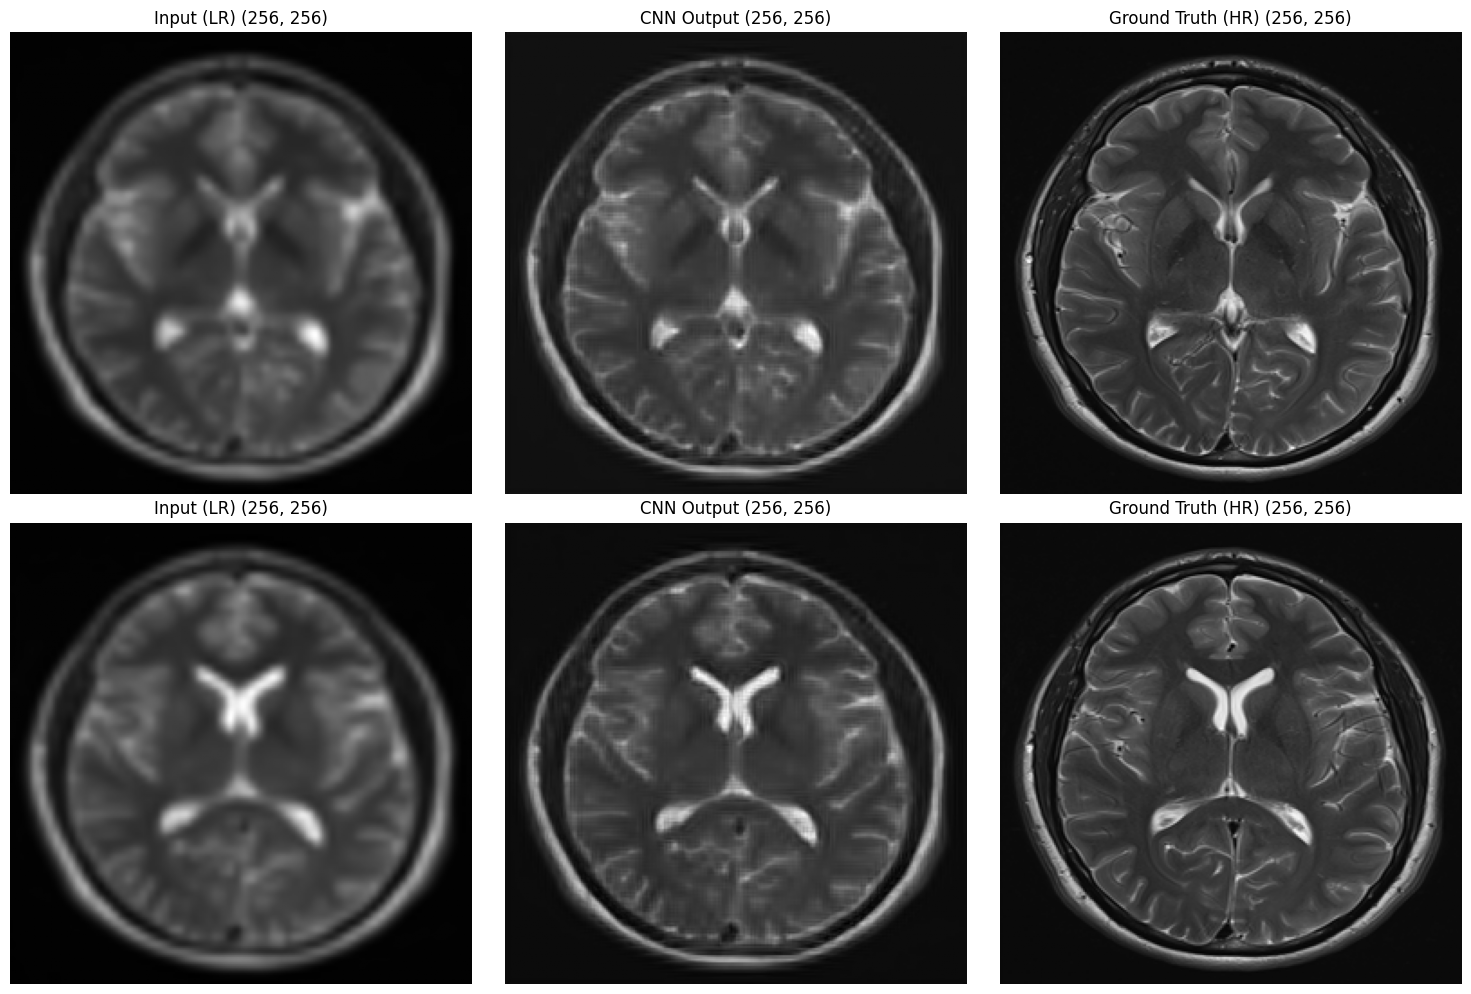

In [ ]:
import matplotlib.pyplot as plt

def visualize_cnn_results(model, dataloader, device, num_samples=2):
    model.eval()
    # Get one batch from the validation loader
    batch = next(iter(dataloader))

    # Pre-process the images just like in the training wrapper
    # Downsample LR to match model input
    lr_input = F.interpolate(batch['lr'], size=(SIZE, SIZE), mode='bicubic').to(device)
    hr_target = batch['hr'].to(device) # Keep as 1-channel for grayscale visualization

    with torch.no_grad():
        # The model outputs a 3-channel 256x256 image
        output = model(lr_input)
        # Convert back to 1-channel grayscale for comparison by taking the mean
        output_gray = torch.mean(output, dim=1, keepdim=True)

    # Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        # 1. Starting Image (LR Input)
        lr_vis = batch['lr'][i].squeeze().cpu().numpy()
        axes[i, 0].imshow(lr_vis, cmap='gray')
        axes[i, 0].set_title(f"Input (LR) {lr_vis.shape}")
        axes[i, 0].axis('off')

        # 2. Output (CNN Prediction)
        out_vis = output_gray[i].squeeze().cpu().numpy()
        axes[i, 1].imshow(out_vis, cmap='gray')
        axes[i, 1].set_title(f"CNN Output {out_vis.shape}")
        axes[i, 1].axis('off')

        # 3. Ground Truth (HR)
        hr_vis = hr_target[i].squeeze().cpu().numpy()
        axes[i, 2].imshow(hr_vis, cmap='gray')
        axes[i, 2].set_title(f"Ground Truth (HR) {hr_vis.shape}")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_cnn_results(cnn_model, val_loader, device)

# Diffusion config args


In [ ]:
import json
import os

# Ensure the directory exists
os.makedirs('./config', exist_ok=True)

config = {
    "name": "mri_resdiff_sr",
    "phase": "train",
    "tag": "resdiff",
    "gpu_ids": [0],
    "path": {
        "log": "logs",
        "tb_logger": "tb_logger",
        "results": "results",
        "checkpoint": "./checkpoints",
        "resume_state": None
    },
    "datasets": {
        "train": { "name": "MRI", "batch_size": 1 },
        "val": { "name": "MRI" }
    },
    "model": {
        "which_model_recon": "sr3",
        "which_model_G": "resdiff", # Added to specify the residual diffusion module
        "finetune_norm": False,
        "beta_schedule": {
            "train": {
                "schedule": "linear",
                "n_timestep": 1000,
                "linear_start": 1e-6,
                "linear_end": 1e-2
            },
            "val": {
                "schedule": "linear",
                "n_timestep": 1000,
                "linear_start": 1e-6,
                "linear_end": 1e-2
            }
        },
        "diffusion": {
            "image_size": SIZE,
            "channels": 1,
            "conditional": True
        },
        "unet": { # THIS SECTION WAS MISSING AND CAUSED THE ERROR
            "in_channel": 5,      # 3 for LR + 3 for noisy residual + 9 for FD Splitter # 1 + 1 + 3
            "out_channel": 1,     # We want the output to also have only one channel
            "inner_channel": 32,
            "use_checkpoint": True,
            "channel_multiplier": [1, 2, 4, 4],
            "attn_res": [8],
            "res_blocks": 1,
            "dropout": 0.2,
            "norm_groups": 16     # Explicitly setting this to avoid the TypeError
        }
    },
    "train": {
        "n_iter": 100000,
        "val_freq": 5000,
        "save_checkpoint_freq": 2000,
        "print_freq": 100,
        "optimizer": {
            "type": "adam",
            "lr": 1e-5
        }
    },
    "wandb": {
        "project": "mri_resdiff_stage2"
    }
}

with open('./config/sr_sr3_16_128.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Configuration updated with 'unet' block.")

Configuration updated with 'unet' block.


# 2. Diffusion

In [ ]:
# Assuming your object is named train_loader
# We access the internal .loader to avoid triggering your custom __iter__
raw_batch = next(iter(train_loader))

print(f"Type of raw_batch: {type(raw_batch)}")

if isinstance(raw_batch, dict):
    print(f"Actual keys found: {list(raw_batch.keys())}")
else:
    print(f"Raw batch is not a dict, it is a {type(raw_batch)}")
    print(f"Content: {raw_batch}")

Type of raw_batch: <class 'dict'>
Actual keys found: ['hr', 'lr', 'txt', 'subject_id', 'instance']


In [ ]:
# Obtains the SR image by passing the LR through the CNN.
class ResDiffDiffusionWrapper:
    def __init__(self, loader, cnn_model, device):
        self.loader = loader
        self.cnn = cnn_model
        self.device = device

    def __iter__(self):
        self.cnn.eval() # Ensure CNN is in inference mode
        for batch in self.loader:
            # Move to device and downsample
            lr = F.interpolate(batch['lr'], size=(SIZE, SIZE), mode='bicubic').to(self.device)
            hr = F.interpolate(batch['hr'], size=(SIZE, SIZE), mode='bicubic').to(self.device)

            with torch.no_grad():
                # Pass through CNN to create the 'SR' image the diffusion model expects
                sr = self.cnn(lr)
                if sr.shape[-1] != SIZE:
                    sr = F.interpolate(sr, size=(SIZE, SIZE), mode='bicubic')

            yield {
                'SR': sr,
                'HR': hr,
                'lr': lr
                # 'txt': batch['txt'],
                # 'subject_id': batch['subject_id'],
                # 'instance': batch['instance'],
            }

    def __len__(self):
        return len(self.loader)

## Trainig loop

In [ ]:
print(train_loader.batch_size)

2


In [ ]:
max_val_images = 5 # Greater than the amount of images in validation set.

In [ ]:
from torch.utils.data import Subset

train_loader_wrp = ResDiffDiffusionWrapper(train_loader, cnn_model, device)

# val_loader = ResDiffDiffusionWrapper(val_loader, cnn_model, device)

full_val_dataset = val_loader.dataset
mini_val_dataset = Subset(full_val_dataset, [0, 1, 2, 3, 4])
val_loader_mini = DataLoader(
    mini_val_dataset,
    batch_size=val_loader.batch_size,
    shuffle=False,
    num_workers=val_loader.num_workers,
    pin_memory=True
)

val_loader_wrp = ResDiffDiffusionWrapper(val_loader_mini, cnn_model, device)
test_loader_wrp = ResDiffDiffusionWrapper(test_loader, cnn_model, device)

# train_loader = ResDiffDiffusionWrapper(train_loader, cnn_model, device)

# val_loader = ResDiffDiffusionWrapper(val_loader, cnn_model, device)

# full_val_dataset = val_loader.dataset
# mini_val_dataset = Subset(full_val_dataset, [0, 1, 2])

# val_loader_mini = DataLoader(
#     mini_val_dataset,
#     batch_size=val_loader.batch_size,
#     shuffle=False,
#     num_workers=val_loader.num_workers,
#     pin_memory=True
# )

# val_loader = ResDiffDiffusionWrapper(val_loader_mini, cnn_model, device)

In [ ]:
import torch
import model as Model
import core.logger as Logger
from argparse import Namespace

# 1. Setup the same configuration used in training
args_nms = Namespace(
    config='./config/sr_sr3_16_128.json',
    phase='test', # Change phase to test
    gpu_ids=None,#[0],   # Set your GPU ID
    debug=False,
    enable_wandb=True,
    log_wandb_ckpt=True,
    log_eval=True
)

opt = Logger.parse(args_nms)
opt = Logger.dict_to_nonedict(opt)

# 2. Initialize the Model Shell
# This creates the UNet architecture (diffusion.netG) based on your JSON config
diffusion = Model.create_model(opt)

# 3. Load your specific checkpoint
checkpoint_path = '/content/drive/MyDrive/GenAI/resdif/last_train_checkpoint.pth'

# We use the fix from our previous step: weights_only=False and manual file opening
with open(checkpoint_path, 'rb') as f:
    checkpoint = torch.load(f, map_location='cuda' if torch.cuda.is_available() else 'cpu', weights_only=False)

# 4. Inject the weights into the network
diffusion.netG.load_state_dict(checkpoint['model_state'])

# 5. Prepare for Inference
diffusion.netG.eval()  # Set to evaluation mode (turns off Dropout/Batchnorm)
phase_to_use = 'val' if 'test' not in opt['model']['beta_schedule'] else 'test'

diffusion.set_new_noise_schedule(
    opt['model']['beta_schedule'][phase_to_use],
    schedule_phase=phase_to_use
)

print(f"Model loaded successfully from step {checkpoint['step']}! Ready for testing.")

export CUDA_VISIBLE_DEVICES=0


TypeError: create_model() got an unexpected keyword argument 'map_location'

In [ ]:
import torch
import data as Data
import model as Model
import logging
import core.logger as Logger
import core.metrics as Metrics
from core.wandb_logger import WandbLogger
import os
import numpy as np
import warnings
import torch.nn.functional as F
from argparse import Namespace
from torch.utils.data import Subset
from torch.cuda.amp import autocast

warnings.filterwarnings("ignore")

# --- MANUALLY SET ARGUMENTS ---
args_nms = Namespace(
    config='./config/sr_sr3_16_128.json',
    phase='train',
    gpu_ids=None,
    debug=False,
    enable_wandb=True,
    log_wandb_ckpt=True,
    log_eval=True
)

opt = Logger.parse(args_nms)
opt = Logger.dict_to_nonedict(opt)

# Logging setupv
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

Logger.setup_logger(None, opt['path']['log'], 'train', level=logging.INFO, screen=True)
Logger.setup_logger('val', opt['path']['log'], 'val', level=logging.INFO)
logger = logging.getLogger('base')

# Initialize WandbLogger
if opt['enable_wandb']:
    import wandb
    wandb_logger = WandbLogger(opt)
    val_step = 0
else:
    wandb_logger = None

# --- 3. DATASET CREATION ---
logger.info('Wrapping existing Notebook DataLoaders...')

logger.info('Initial Dataset Finished')

# Model creation
diffusion = Model.create_model(opt)
logger.info('Initial Model Finished')

# Training Loop
current_step = diffusion.begin_step
current_epoch = diffusion.begin_epoch
n_iter = opt['train']['n_iter']

diffusion.set_new_noise_schedule(
    opt['model']['beta_schedule'][opt['phase']], schedule_phase=opt['phase'])

if opt['phase'] == 'train':
    while current_step < n_iter:
        current_epoch += 1
        for _, train_data in enumerate(train_loader_wrp):
            current_step += 1
            if current_step > n_iter:
                break

            diffusion.feed_data(train_data)
            diffusion.optimize_parameters()

            # Log progress to console and W&B
            if current_step % opt['train']['print_freq'] == 0:
                logs = diffusion.get_current_log()
                message = '<epoch:{:3d}, iter:{:8,d}> '.format(current_epoch, current_step)
                for k, v in logs.items():
                    message += '{:s}: {:.4e} '.format(k, v)
                print(message)

                if wandb_logger:
                    wandb_logger.log_metrics(logs)

            # Validation logic using W&B
            if current_step % opt['train']['val_freq'] == 0:
                # Initialize accumulators
                total_metrics = {'psnr': 0.0, 'ssim': 0.0, 'nmse': 0.0, 'hfen': 0.0}
                idx = 0

                diffusion.set_new_noise_schedule(opt['model']['beta_schedule']['val'], schedule_phase='val')

                for _, val_data in enumerate(val_loader_wrp):
                    if idx >= max_val_images:
                        break

                    idx += 1
                    diffusion.feed_data(val_data)
                    diffusion.test(continous=False)
                    visuals = diffusion.get_current_visuals()

                    # Extract tensors: [B, C, H, W]
                    sr_tensor = visuals['SR']
                    hr_tensor = visuals['HR']

                    # Compute metrics using your provided function
                    p, s, n, h = compute_mri_metrics(sr_tensor, hr_tensor)

                    total_metrics['psnr'] += p
                    total_metrics['ssim'] += s
                    total_metrics['nmse'] += n
                    total_metrics['hfen'] += h

                    # Log visual samples to W&B
                    if wandb_logger and idx <= 5:
                        lr_img = Metrics.tensor2img(visuals['LR'][0])
                        sr_img = Metrics.tensor2img(visuals['SR'][0])
                        hr_img = Metrics.tensor2img(visuals['HR'][0])
                        wandb_logger.log_image(f'val_{idx}', np.concatenate((lr_img, sr_img, hr_img), axis=1))

                # Average metrics over the validation set
                avg_metrics = {f'validation/avg_{k}': v / idx for k, v in total_metrics.items()}
                avg_metrics['validation/val_step'] = val_step

                # Resume training noise schedule
                diffusion.set_new_noise_schedule(opt['model']['beta_schedule']['train'], schedule_phase='train')

                if wandb_logger:
                    wandb_logger.log_metrics(avg_metrics)
                    val_step += 1

            if current_step % opt['train']['save_checkpoint_freq'] == 0:
                diffusion.save_network(current_epoch, current_step)

    logger.info('End of training.')

In [ ]:
# # Define your path
save_path = "trained_unet.pth"

# Access the underlying torch model
# In this framework, it's usually diffusion.netG
torch.save(diffusion.netG.state_dict(), save_path)

print(f"Model weights saved to {save_path}")

In [ ]:
# # This saves the 'brain' of the training process
torch.save({
    'epoch': current_epoch,
    'step': current_step,
    'opt_state': diffusion.optG.state_dict(), # Optimizer state
    'model_state': diffusion.netG.state_dict()
}, 'last_train_checkpoint.pth')

In [ ]:
# List all parts of the diffusion object
for attr in dir(diffusion):
    if 'net' in attr or 'opt' in attr:
        print(f"Found component: {attr}")

In [ ]:
import numpy as np
import torch
from IPython.display import clear_output

# 1. PRE-CHECK: Only initialize if this is the FIRST time running
# This prevents the results from being wiped if you rerun the cell
if 'test_results' not in locals():
    test_results = {'psnr': [], 'ssim': [], 'nmse': [], 'hfen': []}
    processed_indices = set() # To track what we've already done
    print("Initialized new results containers.")
else:
    print(f"Resuming evaluation. Already have {len(test_results['psnr'])} samples.")

# 2. Evaluation Loop with Error Handling
with torch.no_grad():
    # Use enumerate to keep track of the index
    for i, test_data in enumerate(test_loader_wrp):

        # Skip if we already processed this index in a previous run
        if i in processed_indices:
            continue

        try:
            diffusion.feed_data(test_data)
            diffusion.test(continous=False)

            visuals = diffusion.get_current_visuals()

            # Compute metrics
            p, s, nmse, hfen = compute_mri_metrics(visuals['SR'], visuals['HR'])

            # Store results
            test_results['psnr'].append(p)
            test_results['ssim'].append(s)
            test_results['nmse'].append(nmse)
            test_results['hfen'].append(hfen)
            processed_indices.add(i)

            # LIVE UPDATE
            if i % 1 == 0: # Update every step
                avg_p = np.mean(test_results['psnr'])
                avg_s = np.mean(test_results['ssim'])
                avg_n = np.mean(test_results['nmse'])
                avg_h = np.mean(test_results['hfen'])

                clear_output(wait=True)
                print("="*40)
                print(f" PROGRESS: Batch {i+1}/{len(test_loader_wrp)}")
                print(f" SAMPLES COLLECTED: {len(processed_indices)}")
                print("-"*40)
                print(f" CURRENT RUNNING AVERAGES:")
                print(f" PSNR: {avg_p:.4f} | SSIM: {avg_s:.4f}")
                print(f" NMSE: {avg_n:.4e} | HFEN: {avg_h:.4f}")
                print("="*40)

        except FileNotFoundError as e:
            print(f"\n[SKIP] Missing file at index {i}: {e}")
            continue # Move to the next batch
        except Exception as e:
            print(f"\n[ERROR] Unexpected error at index {i}: {e}")
            continue

# 3. Final Summary (only prints when the loop actually finishes)
if len(test_results['psnr']) > 0:
    final_metrics = {k: np.mean(v) for k, v in test_results.items()}
    print("\n" + "!"*40)
    print(" FINAL EVALUATION COMPLETE ")
    for m in final_metrics:
        print(f"{m.upper():4}: {final_metrics[m]:.4f}")

# Clean

In [ ]:
import sys

# Get a list of all sub-modules belonging to your project
modules_to_delete = [name for name in sys.modules if name.startswith('model') or name.startswith('core') or 'ResDiff' in name]

for module in modules_to_delete:
    del sys.modules[module]

print(f"Purged {len(modules_to_delete)} modules. Now re-run your import cell.")